In [1]:
# Sel persiapan tambahan, bukan listing buku.
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (8, 4.6),
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Semua contoh memakai data kecil yang ditulis langsung di notebook.')

Python: 3.13.16
NumPy: 2.1.3
Matplotlib: 3.10.0
Semua contoh memakai data kecil yang ditulis langsung di notebook.


## 2. Ringkasan Chapter 4

Pembelajaran dimulai dengan membuat prediksi dan membandingkannya dengan target. Pada contoh satu bobot, prediksi dihitung sebagai hasil perkalian input dan bobot. Squared error mengukur besar kesalahan tanpa membedakan tanda positif atau negatif, sedangkan residual tetap menyimpan informasi apakah prediksi terlalu tinggi atau terlalu rendah.

Metode pertama adalah hot and cold learning. Bobot dicoba sedikit lebih besar dan sedikit lebih kecil, lalu arah dengan error lebih kecil dipilih. Cara ini mudah dipahami, tetapi memerlukan beberapa evaluasi dan menggunakan ukuran langkah tetap. Implementasi lengkap buku dapat terus bergerak di sekitar optimum karena hanya membandingkan dua kandidat tetangga.

Gradient descent mengganti percobaan dua arah dengan perhitungan gradien. Pada kode buku, residual dikalikan input untuk memperoleh `weight_delta`, kemudian nilai itu dikurangkan dari bobot. Turunan menjelaskan sensitivitas lokal fungsi loss terhadap perubahan bobot. Learning rate `alpha` mengatur besar pembaruan.

Contoh berikutnya menunjukkan bahwa langkah pembelajaran dapat terlalu besar: prediksi bergantian melewati target dan semakin menjauh. Alpha yang sesuai membuat pembelajaran kembali mendekati optimum. Untuk model satu sampel dan satu bobot ini, notebook juga menurunkan syarat konvergensi secara analitis dan memeriksanya melalui eksperimen.

Loss kecil pada satu observasi menunjukkan kecocokan terhadap observasi tersebut. Hal itu belum membuktikan kemampuan model pada data baru. Bab ini menjadi dasar untuk memahami pembelajaran jaringan dengan lebih banyak bobot.

**Rujukan:** Trask (2019), hlm. 47-77.

## 3. Peta subbab dan cakupan reproduksi

| Subbab dalam buku | Halaman cetak | Cakupan notebook |
| --- | --- | --- |
| Predict, compare, and learn | 48-49 | Siklus pembelajaran dan peran setiap tahap |
| Compare: Does your network make good predictions? | 50 | Prediksi, residual, dan squared error |
| Why measure error? | 51 | Alasan mengukur error dan perbandingan dengan absolute error |
| What's the simplest form of neural learning? | 52-53 | Satu iterasi hot and cold, termasuk koreksi salah ketik |
| Hot and cold learning | 54 | Loop 1.101 iterasi; semua update dijalankan |
| Characteristics of hot and cold learning | 55 | Keterbatasan langkah tetap; eksperimen langkah 0,2 dan 10 |
| Calculating both direction and amount from error | 56-57 | Loop 20 iterasi dan peran perkalian input |
| One iteration of gradient descent | 58-59 | `delta`, `weight_delta`, dan `alpha` |
| Learning is just reducing error | 60-61 | Empat iterasi dengan input 0,5 dan bentuk kurva loss |
| Let's watch several steps of learning | 62-63 | Empat iterasi dengan input 1,1 |
| Why does this work? What is weight_delta, really? | 64-65 | Fungsi, parameter, dan nilai yang dipertahankan |
| Tunnel vision on one concept | 66 | Hubungan bobot dengan error; loop berulang dirujuk |
| A box with rods poking out of it | 67 | Reproduksi persamaan batang dan analogi turunan |
| Derivatives: Take two | 68 | Turunan sebagai kemiringan lokal; grafik tambahan |
| What you really need to know / What you don't really need to know | 69 | Persamaan ilustratif, domain, dan inti kalkulus |
| How to use a derivative to learn | 70 | Arah update; klarifikasi faktor 2 pada loss |
| Look familiar? | 71 | Listing sama dengan hlm. 62, digabung di bagian 14 |
| Breaking gradient descent | 72 | Baseline input 0,5 dan percobaan input 2 |
| Visualizing overcorrections / Divergence | 73-74 | Analisis tiga iterasi awal dan pertumbuhan error |
| Introducing alpha / Alpha in code | 75-76 | Loop dengan alpha 0,1 dan variasi alpha |
| Memorizing | 77 | Latihan menulis ulang dan refleksi pribadi |

Sel reproduksi mempertahankan rumus, nilai awal, dan jumlah iterasi buku. Pencatatan trajectory serta keluaran tambahan digunakan untuk analisis. Pada loop hot and cold yang panjang, **hanya frekuensi pencetakan yang diringkas**, bukan jumlah update.

## 4. Predict, compare, dan learn

Model pada bab ini menggunakan satu input $x$, satu bobot $w$, dan target $y$, tanpa bias maupun activation function:

$$
\hat{y}=xw
$$

**Predict:** hitung $\hat{y}$ menggunakan bobot saat ini. **Compare:** hitung selisih terhadap target dan nilai loss. **Learn:** ubah bobot agar loss berkurang pada iterasi berikutnya.

| Simbol / variabel | Arti | Nilai dapat berubah ketika belajar? |
| --- | --- | --- |
| $x$ / `input_data` | Masukan observasi | Dipertahankan pada contoh ini |
| $y$ / `goal_pred` | Target observasi | Dipertahankan |
| $w$ / `weight` | Parameter pengali input | Ya, diperbarui |
| $\hat{y}$ / `pred` | Prediksi model | Dihitung ulang dari bobot |
| $E$ / `error` | Squared error | Dihitung ulang dari prediksi |
| $\alpha$ / `alpha` | Learning rate | Dipilih sebelum loop pada contoh buku |

Pembelajaran bukan mengubah target agar sama dengan prediksi. Target dan input menjadi acuan; bobot adalah parameter yang dicari. Istilah *attribution* pada bab ini merujuk pada peran bobot terhadap kesalahan dan bagaimana peran itu digunakan untuk menentukan update.

**Rujukan:** Trask (2019), hlm. 48-49 dan 64-66.

## 5. Compare: mengukur kesalahan prediksi

**Asal kode:** reproduksi hlm. 50. Buku menggunakan `knob_weight = 0.5`, input `0.5`, dan target `0.8`.

Residual menyimpan arah kesalahan:

$$\delta=\hat{y}-y$$

Squared error mengukur besarnya kesalahan:

$$E=(\hat{y}-y)^2$$

Pada contoh ini, prediksi $0.25$, residual $-0.55$, dan squared error $0.3025$. Residual negatif berarti prediksi lebih rendah daripada target. Squared error selalu **nonnegatif**, termasuk nol jika prediksi tepat. Tanda residual hilang ketika dikuadratkan.

Untuk $n$ sampel, mean squared error adalah $\mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2$. Dengan satu sampel, squared error dan MSE bernilai sama.

In [2]:
# Reproduksi hlm. 50; input -> input_data.
knob_weight = 0.5
input_data = 0.5
goal_pred = 0.8

pred = input_data * knob_weight
error = (pred - goal_pred) ** 2
print(error)

# Keluaran pendamping untuk memisahkan residual dan loss.
compare_result = {'prediction': pred, 'residual': pred - goal_pred, 'error': error}
print('Prediction:', pred)
print('Residual:', pred - goal_pred)
print('Squared error:', error)

0.30250000000000005
Prediction: 0.25
Residual: -0.55
Squared error: 0.30250000000000005


## 6. Why measure error?

Nilai loss menyediakan ukuran yang dapat dibandingkan antar pilihan bobot. Menggunakan rata-rata residual bertanda dapat menyesatkan: residual positif dan negatif saling meniadakan, walaupun setiap prediksi meleset jauh.

Absolute error $|\hat{y}-y|$ juga nonnegatif. Squared error memberikan penalti lebih besar pada residual besar dan memiliki turunan yang sederhana. Pilihan loss memengaruhi apa yang dioptimalkan; loss yang kecil bukan satu-satunya ukuran kualitas untuk semua tugas.

**Asal kode berikut:** ilustrasi tambahan untuk penjelasan hlm. 51, bukan listing buku. Dua residual `1000` dan `-1000` mempunyai rata-rata nol, tetapi MSE satu juta. Grafik dan perhitungan bab ini selanjutnya memakai squared error.

**Rujukan:** Trask (2019), hlm. 50-51.

In [3]:
# Ilustrasi tambahan: tanda residual dapat saling meniadakan.
residuals = np.array([1000.0, -1000.0])
print('Residual:', residuals)
print('Rata-rata residual bertanda:', np.mean(residuals))
print('Mean absolute error:', np.mean(np.abs(residuals)))
print('Mean squared error:', np.mean(residuals ** 2))

small_and_large = np.array([0.1, 1.0, 2.0])
print()
print('Residual | Absolute error | Squared error')
for residual in small_and_large:
    print(f'{residual:8.1f} | {abs(residual):14.2f} | {residual ** 2:13.2f}')

Residual: [ 1000. -1000.]
Rata-rata residual bertanda: 0.0
Mean absolute error: 1000.0
Mean squared error: 1000000.0

Residual | Absolute error | Squared error
     0.1 |           0.10 |          0.01
     1.0 |           1.00 |          1.00
     2.0 |           2.00 |          4.00


## 7. Satu iterasi hot and cold learning

**Asal kode:** reproduksi gabungan langkah hlm. 52-53. Mulai dari `weight = 0.1`, input `8.5`, dan target `1`. Metode ini mengevaluasi bobot saat ini, kandidat lebih besar, serta kandidat lebih kecil.

| Kandidat bobot | Prediksi | Squared error |
| --- | --- | --- |
| $0.10$ | $0.850$ | $0.022500$ |
| $0.11$ | $0.935$ | $0.004225$ |
| $0.09$ | $0.765$ | $0.055225$ |

Bobot dinaikkan karena kandidat `0.11` menghasilkan error lebih kecil daripada bobot saat ini dan kandidat turun.

**Koreksi pada listing/diagram halaman 53:**

| Teks pada buku | Penyesuaian reproduksi | Alasan |
| --- | --- | --- |
| `lr = 0.1` pada bagian kandidat naik | `lr = 0.01` | Sesuai bobot kandidat `0.11` dan angka contoh |
| Operator `\|\|` | Operator Python `or` | `\|\|` bukan sintaks Python |
| `if(e_up < e_up)` | `if e_up < e_dn` | Perbandingan terhadap dirinya sendiri selalu salah |

Di sini `lr` adalah ukuran perturbasi hot and cold, bukan pengali gradien. Koreksi tersebut membuat langkah yang dijelaskan buku dapat dijalankan; loop lengkap pada halaman 54 direproduksi tersendiri setelahnya.

In [4]:
# Reproduksi gabungan hlm. 52-53 dengan koreksi yang dijelaskan di atas.
weight = 0.1
lr = 0.01

def neural_network(input_data, weight):
    prediction = input_data * weight
    return prediction

number_of_toes = [8.5]
win_or_lose_binary = [1]
input_data = number_of_toes[0]
true = win_or_lose_binary[0]

pred = neural_network(input_data, weight)
error = (pred - true) ** 2

p_up = neural_network(input_data, weight + lr)
e_up = (p_up - true) ** 2
p_dn = neural_network(input_data, weight - lr)
e_dn = (p_dn - true) ** 2

print(f'Saat ini: w={weight:.2f}, pred={pred:.3f}, error={error:.6f}')
print(f'Naik    : w={weight + lr:.2f}, pred={p_up:.3f}, error={e_up:.6f}')
print(f'Turun   : w={weight - lr:.2f}, pred={p_dn:.3f}, error={e_dn:.6f}')

if error > e_dn or error > e_up:
    if e_dn < e_up:
        weight -= lr
    if e_up < e_dn:
        weight += lr

hot_cold_one_step = {
    'current_error': error, 'up_error': e_up, 'down_error': e_dn,
    'new_weight': weight,
}
print('Bobot baru:', weight)
print('Prediksi baru:', neural_network(input_data, weight))

Saat ini: w=0.10, pred=0.850, error=0.022500
Naik    : w=0.11, pred=0.935, error=0.004225
Turun   : w=0.09, pred=0.765, error=0.055225
Bobot baru: 0.11
Prediksi baru: 0.935


## 8. Hot and cold learning: kode lengkap

**Asal kode:** reproduksi hlm. 54. Semua **1.101 iterasi** dijalankan. Angka awal, langkah `0.001`, dua evaluasi kandidat, dan kedua kondisi update dipertahankan. Tambahan `hot_cold_history` menyimpan hasil sebelum update; pencetakan dibatasi pada tiga iterasi pertama, kelipatan 200, dan tiga iterasi terakhir agar output mudah dibaca.

Loop ini berbeda dari langkah halaman 53: ia hanya membandingkan error kandidat naik dengan kandidat turun, **tanpa membandingkan kandidat terbaik terhadap error saat ini**. Akibatnya, ketika bobot sudah sangat dekat dengan optimum, loop dapat tetap mengubah bobot dan menjauh pada langkah berikutnya. Perbedaan ini dipertahankan dalam reproduksi.

In [5]:
# Reproduksi hlm. 54; hanya logging dan penyimpanan history yang ditambahkan.
weight = 0.5
input_data = 0.5
goal_prediction = 0.8
step_amount = 0.001
hot_cold_history = []

for iteration in range(1101):
    prediction = input_data * weight
    error = (prediction - goal_prediction) ** 2
    hot_cold_history.append({
        'iteration': iteration, 'weight': weight,
        'prediction': prediction, 'error': error,
    })

    if iteration < 3 or iteration % 200 == 0 or iteration >= 1098:
        print(f'Iterasi {iteration:4d} | Error:{error} Prediction:{prediction}')

    up_prediction = input_data * (weight + step_amount)
    up_error = (goal_prediction - up_prediction) ** 2
    down_prediction = input_data * (weight - step_amount)
    down_error = (goal_prediction - down_prediction) ** 2

    if down_error < up_error:
        weight = weight - step_amount
    if down_error > up_error:
        weight = weight + step_amount

hot_cold_final_weight = weight
hot_cold_final_pred = input_data * weight
hot_cold_final_error = (hot_cold_final_pred - goal_prediction) ** 2
print()
print('Setelah update terakhir:')
print('Weight:', hot_cold_final_weight)
print('Prediction:', hot_cold_final_pred)
print('Error:', hot_cold_final_error)

Iterasi    0 | Error:0.30250000000000005 Prediction:0.25
Iterasi    1 | Error:0.3019502500000001 Prediction:0.2505
Iterasi    2 | Error:0.30140100000000003 Prediction:0.251
Iterasi  200 | Error:0.20249999999999996 Prediction:0.3500000000000001
Iterasi  400 | Error:0.1224999999999999 Prediction:0.4500000000000002
Iterasi  600 | Error:0.06250000000000266 Prediction:0.5499999999999947
Iterasi  800 | Error:0.0225000000000049 Prediction:0.6499999999999837
Iterasi 1000 | Error:0.0025000000000027357 Prediction:0.7499999999999727
Iterasi 1098 | Error:1.000000000065505e-06 Prediction:0.7989999999999673
Iterasi 1099 | Error:2.5000000003280753e-07 Prediction:0.7994999999999672
Iterasi 1100 | Error:1.0799505792475652e-27 Prediction:0.7999999999999672

Setelah update terakhir:
Weight: 1.6009999999999343
Prediction: 0.8004999999999671
Error: 2.4999999996708233e-07


### Membaca hasil loop panjang

Dengan $x=0.5$ dan $y=0.8$, bobot yang tepat adalah $w^*=y/x=1.6$. Pada log iterasi `1100`, bobot sebelum update hampir `1.6` dan error mendekati nol. Sesudah update terakhir, bobot menjadi sekitar `1.601` dan error sekitar $2.5\times10^{-7}$.

Jadi, nilai error pada baris log terakhir bukan error dari bobot akhir setelah seluruh update. Ini juga menunjukkan mengapa loop halaman 54 dapat berosilasi. Perbedaan kecil pada representasi desimal disebabkan floating point; misalnya nilai yang secara matematis `0.3025` dapat ditampilkan sebagai `0.30250000000000005`.

**Tambahan analitis:** loop dapat diperbaiki dengan mensyaratkan kandidat lebih baik daripada bobot saat ini atau menghentikan pembelajaran saat loss memenuhi toleransi. Perbaikan itu tidak diterapkan diam-diam pada reproduksi di atas.

## 9. Characteristics of hot and cold learning

Setiap iterasi menghitung tiga prediksi: prediksi saat ini, kandidat naik, dan kandidat turun. Untuk lebih banyak bobot, pencarian seperti ini membutuhkan semakin banyak evaluasi. Ukuran langkah juga dipilih secara manual: langkah kecil memerlukan banyak iterasi, sedangkan langkah besar dapat melewati optimum.

Dengan langkah tetap, bobot hanya mengunjungi titik-titik pada grid yang ditentukan bobot awal dan ukuran langkah. Jika optimum berada di antara titik grid, loop tidak dapat mencapainya persis. Bahkan ketika optimum dapat dicapai, logika halaman 54 dapat kembali bergerak dari titik tersebut.

**Asal kode berikut:** eksperimen tambahan untuk pertanyaan buku hlm. 55 tentang `step_amount = 0.2` dan `10`. Fungsi membungkus logika halaman 54 tanpa mengubah aturan update. Dengan langkah `10`, contoh ini bergantian antara error `0.3025` dan `19.8025`; kandidat yang dipilih pada suatu langkah belum tentu lebih baik daripada bobot saat ini.

**Rujukan:** Trask (2019), hlm. 54-55.

In [6]:
# Eksperimen tambahan: helper memakai aturan update hot and cold halaman 54.
def run_hot_cold(step_amount, iterations=12):
    weight = 0.5
    input_data = 0.5
    goal_prediction = 0.8
    history = []
    for iteration in range(iterations):
        prediction = input_data * weight
        error = (prediction - goal_prediction) ** 2
        history.append((iteration, weight, prediction, error))
        up_error = (goal_prediction - input_data * (weight + step_amount)) ** 2
        down_error = (goal_prediction - input_data * (weight - step_amount)) ** 2
        if down_error < up_error:
            weight = weight - step_amount
        if down_error > up_error:
            weight = weight + step_amount
    return history, weight

hot_cold_variations = {}
for step in [0.2, 10.0]:
    history, final_weight = run_hot_cold(step)
    hot_cold_variations[step] = history
    print()
    print(f'step_amount = {step}')
    print('Iterasi | Weight | Prediction | Error sebelum update')
    for iteration, weight_before, prediction, error in history:
        print(f'{iteration:7d} | {weight_before:6.2f} | {prediction:10.3f} | {error:.6f}')


step_amount = 0.2
Iterasi | Weight | Prediction | Error sebelum update
      0 |   0.50 |      0.250 | 0.302500
      1 |   0.70 |      0.350 | 0.202500
      2 |   0.90 |      0.450 | 0.122500
      3 |   1.10 |      0.550 | 0.062500
      4 |   1.30 |      0.650 | 0.022500
      5 |   1.50 |      0.750 | 0.002500
      6 |   1.70 |      0.850 | 0.002500
      7 |   1.50 |      0.750 | 0.002500
      8 |   1.70 |      0.850 | 0.002500
      9 |   1.50 |      0.750 | 0.002500
     10 |   1.70 |      0.850 | 0.002500
     11 |   1.50 |      0.750 | 0.002500

step_amount = 10.0
Iterasi | Weight | Prediction | Error sebelum update
      0 |   0.50 |      0.250 | 0.302500
      1 |  10.50 |      5.250 | 19.802500
      2 |   0.50 |      0.250 | 0.302500
      3 |  10.50 |      5.250 | 19.802500
      4 |   0.50 |      0.250 | 0.302500
      5 |  10.50 |      5.250 | 19.802500
      6 |   0.50 |      0.250 | 0.302500
      7 |  10.50 |      5.250 | 19.802500
      8 |   0.50 |      0.250 |

## 10. Menghitung direction and amount dari error

**Asal kode:** reproduksi hlm. 56; listing yang sama pada hlm. 65 digabung di sini. Algoritma menghitung:

$$g=(\hat{y}-y)x,\qquad w_{t+1}=w_t-g$$

`direction_and_amount` berperan sebagai gradien untuk loss setengah squared error, sebagaimana dijelaskan di bagian 17. Pembaruan ini mempunyai learning rate implisit $\alpha=1$. Berbeda dari hot and cold, kode tidak perlu mencoba dua bobot tetangga terlebih dahulu.

Perkalian residual dengan input memperhitungkan sensitivitas prediksi terhadap bobot. Residual saja belum menentukan arah update dengan benar ketika input negatif. Nilai gradien memberi arah penurunan lokal; keberhasilan langkah finite juga bergantung pada learning rate.

In [7]:
# Reproduksi hlm. 56 dan 65; semua 20 baris output ditampilkan.
weight = 0.5
goal_pred = 0.8
input_data = 0.5
direction_history = []

for iteration in range(20):
    pred = input_data * weight
    error = (pred - goal_pred) ** 2
    direction_and_amount = (pred - goal_pred) * input_data
    direction_history.append({
        'iteration': iteration, 'weight': weight,
        'prediction': pred, 'error': error, 'gradient': direction_and_amount,
    })
    weight = weight - direction_and_amount
    print('Error:' + str(error) + ' Prediction:' + str(pred))

direction_final_weight = weight
direction_final_pred = input_data * weight
direction_final_error = (direction_final_pred - goal_pred) ** 2
print()
print('Setelah update ke-20:')
print('Weight:', direction_final_weight)
print('Prediction:', direction_final_pred)
print('Error:', direction_final_error)

Error:0.30250000000000005 Prediction:0.25
Error:0.17015625000000004 Prediction:0.3875
Error:0.095712890625 Prediction:0.49062500000000003
Error:0.05383850097656251 Prediction:0.56796875
Error:0.03028415679931642 Prediction:0.6259765625
Error:0.0170348381996155 Prediction:0.669482421875
Error:0.00958209648728372 Prediction:0.70211181640625
Error:0.005389929274097089 Prediction:0.7265838623046875
Error:0.0030318352166796153 Prediction:0.7449378967285156
Error:0.0017054073093822882 Prediction:0.7587034225463867
Error:0.0009592916115275371 Prediction:0.76902756690979
Error:0.0005396015314842384 Prediction:0.7767706751823426
Error:0.000303525861459885 Prediction:0.7825780063867569
Error:0.00017073329707118678 Prediction:0.7869335047900676
Error:9.603747960254256e-05 Prediction:0.7902001285925507
Error:5.402108227642978e-05 Prediction:0.7926500964444131
Error:3.038685878049206e-05 Prediction:0.7944875723333098
Error:1.7092608064027242e-05 Prediction:0.7958656792499823
Error:9.614592036015323

## 11. Scaling, negative reversal, dan stopping

Tiga peran perkalian dengan input pada hlm. 57 dapat dijelaskan dari $g=x(\hat{y}-y)$:

- **Scaling:** besar input memengaruhi besar gradien. Input yang besar juga membuat prediksi lebih sensitif terhadap perubahan bobot.
- **Negative reversal:** ketika input negatif, menaikkan bobot menurunkan prediksi. Tanda input membalik arah update yang diperlukan.
- **Stopping:** jika input nol, gradien bobot ini nol. Model $\hat{y}=xw$ selalu memprediksi nol untuk input tersebut, sehingga perubahan bobot tidak membantu mencapai target yang bukan nol.

**Asal kode berikut:** ilustrasi tambahan satu langkah pada input negatif, nol, dan positif. Untuk $x=-0.5$, prediksi berada di bawah target, tetapi bobot perlu turun agar prediksi naik. Untuk $x=0$, error tetap `0.64` setelah update.

Kasus input nol tidak berarti semua neural network berhenti belajar; kesimpulan ini hanya menyangkut bobot pada model satu input **tanpa bias** yang dipakai di bab ini.

**Rujukan:** Trask (2019), hlm. 56-57.

In [8]:
# Ilustrasi tambahan: pengaruh tanda dan nilai input.
print('Input | Pred awal | Residual | Gradient | Weight baru | Pred baru | Error baru')
input_effect_results = []
for x_value in [-0.5, 0.0, 0.5]:
    w_value = 0.5
    target = 0.8
    pred_before = x_value * w_value
    residual = pred_before - target
    gradient = x_value * residual
    w_after = w_value - gradient
    pred_after = x_value * w_after
    loss_after = (pred_after - target) ** 2
    input_effect_results.append((x_value, w_after, loss_after))
    print(f'{x_value:5.1f} | {pred_before:9.3f} | {residual:8.3f} | '
          f'{gradient:8.3f} | {w_after:11.3f} | {pred_after:9.3f} | {loss_after:.6f}')

Input | Pred awal | Residual | Gradient | Weight baru | Pred baru | Error baru
 -0.5 |    -0.250 |   -1.050 |    0.525 |      -0.025 |     0.013 | 0.620156
  0.0 |     0.000 |   -0.800 |   -0.000 |       0.500 |     0.000 | 0.640000
  0.5 |     0.250 |   -0.550 |   -0.275 |       0.775 |     0.388 | 0.170156


## 12. One iteration of gradient descent

**Asal kode:** reproduksi gabungan hlm. 58-59. Contoh kembali memakai input `8.5`, target `1`, bobot `0.1`, dan learning rate `alpha = 0.01`.

Urutan perhitungannya adalah:

$$
\hat{y}=xw,\quad E=(\hat{y}-y)^2,\quad
\delta=\hat{y}-y,\quad g=x\delta,\quad
w_{\mathrm{baru}}=w-\alpha g
$$

`delta` adalah kesalahan pada output. `weight_delta` adalah gradien terhadap bobot untuk $J=\tfrac12E$, **bukan** perubahan bobot aktual. Perubahan aktual adalah $\Delta w=-\alpha\,\texttt{weight_delta}$.

Secara matematis, `delta = -0.15`, `weight_delta = -1.275`, dan bobot baru `0.11275`. Diagram halaman 59 menampilkan `-1.25` dan `0.1125`; angka tersebut tidak sama dengan hasil formula yang tercetak. Notebook mengikuti hasil perhitungan kode. Prediksi setelah update menjadi `0.958375` dan error sekitar `0.001732640625`.

In [9]:
# Reproduksi gabungan hlm. 58-59.
weight = 0.1
alpha = 0.01

def neural_network(input_data, weight):
    prediction = input_data * weight
    return prediction

number_of_toes = [8.5]
win_or_lose_binary = [1]
input_data = number_of_toes[0]
goal_pred = win_or_lose_binary[0]

pred = neural_network(input_data, weight)
error = (pred - goal_pred) ** 2
delta = pred - goal_pred
weight_delta = input_data * delta
weight_before = weight
weight -= weight_delta * alpha

one_gradient_step = {
    'prediction': pred, 'error': error, 'delta': delta,
    'weight_delta': weight_delta, 'new_weight': weight,
    'new_prediction': neural_network(input_data, weight),
    'new_error': (neural_network(input_data, weight) - goal_pred) ** 2,
}
print('Prediction sebelum update:', pred)
print('Error sebelum update:', error)
print('Delta:', delta)
print('Weight delta:', weight_delta)
print('Perubahan bobot aktual:', weight - weight_before)
print('Weight baru:', weight)
print('Prediction sesudah update:', one_gradient_step['new_prediction'])
print('Error sesudah update:', one_gradient_step['new_error'])

Prediction sebelum update: 0.8500000000000001
Error sebelum update: 0.022499999999999975
Delta: -0.1499999999999999
Weight delta: -1.2749999999999992
Perubahan bobot aktual: 0.012749999999999997
Weight baru: 0.11275
Prediction sesudah update: 0.958375
Error sesudah update: 0.001732640625000002


## 13. Learning is just reducing error

**Asal kode:** reproduksi hlm. 60. Bobot awal `0.0`, target `0.8`, dan input `0.5`. Empat iterasi dijalankan tanpa alpha eksplisit, sehingga learning rate efektifnya `1`.

Prediksi sebelum update berturut-turut adalah `0`, `0.2`, `0.35`, dan `0.4625`. Error berkurang dari `0.64` menjadi `0.11390625` pada log keempat. Bobot akhir setelah update keempat berbeda dari bobot yang digunakan untuk log keempat.

Untuk input dan target tetap, loss menjadi fungsi bobot:

$$E(w)=(0.5w-0.8)^2$$

Kurva ini berbentuk parabola dengan titik minimum $w^*=1.6$. Pada contoh ini, ada bobot yang menghasilkan error nol karena satu persamaan dapat dipenuhi oleh satu bobot dan input tidak nol. Kesimpulan tersebut tidak otomatis berlaku untuk dataset besar dengan target yang saling tidak cocok atau mengandung noise.

**Rujukan:** Trask (2019), hlm. 60-61.

In [10]:
# Reproduksi hlm. 60.
weight, goal_pred, input_data = (0.0, 0.8, 0.5)
four_half_history = []

for iteration in range(4):
    pred = input_data * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = delta * input_data
    four_half_history.append({
        'iteration': iteration, 'weight': weight, 'prediction': pred,
        'error': error, 'delta': delta, 'gradient': weight_delta,
    })
    weight = weight - weight_delta
    print('Error:' + str(error) + ' Prediction:' + str(pred))

four_half_final_weight = weight
print('Weight setelah 4 update:', weight)
print('Prediction setelah 4 update:', input_data * weight)
print('Error setelah 4 update:', (input_data * weight - goal_pred) ** 2)

Error:0.6400000000000001 Prediction:0.0
Error:0.3600000000000001 Prediction:0.2
Error:0.2025 Prediction:0.35000000000000003
Error:0.11390625000000001 Prediction:0.4625
Weight setelah 4 update: 1.09375
Prediction setelah 4 update: 0.546875
Error setelah 4 update: 0.06407226562500003


## 14. Let's watch several steps of learning

**Asal kode:** reproduksi hlm. 62; listing identik pada hlm. 71 digabung di sini. Input dinaikkan menjadi `1.1`, bobot awal tetap `0`, dan target `0.8`.

Prediksi pertama setelah satu update adalah `0.968`, sehingga melewati target. Update berikutnya menurunkan bobot dan menghasilkan prediksi `0.76472`. Iterasi berikutnya kembali melewati target, tetapi besar kesalahan mengecil.

**Melewati target belum berarti divergence.** Jika jarak terhadap optimum mengecil, perpindahan bergantian di kedua sisi optimum dapat tetap konvergen. Untuk kasus ini, faktor perubahan jarak bobot adalah $1-1.1^2=-0.21$. Tanda negatif menjelaskan pergantian sisi; besar faktor yang kurang dari satu menjelaskan penyusutan jarak. Penurunan rumusnya diberikan di bagian 23.

**Rujukan:** Trask (2019), hlm. 62-63 dan 71.

In [11]:
# Reproduksi hlm. 62 dan 71; history ditambahkan untuk analisis.
weight, goal_pred, input_data = (0.0, 0.8, 1.1)
four_large_history = []

for iteration in range(4):
    print('-----\nWeight:' + str(weight))
    pred = input_data * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = delta * input_data
    four_large_history.append({
        'iteration': iteration, 'weight': weight, 'prediction': pred,
        'error': error, 'delta': delta, 'gradient': weight_delta,
    })
    weight = weight - weight_delta
    print('Error:' + str(error) + ' Prediction:' + str(pred))
    print('Delta:' + str(delta) + ' Weight Delta:' + str(weight_delta))

four_large_final_weight = weight
print('Weight setelah 4 update:', weight)
print('Weight optimum:', goal_pred / input_data)

-----
Weight:0.0
Error:0.6400000000000001 Prediction:0.0
Delta:-0.8 Weight Delta:-0.8800000000000001
-----
Weight:0.8800000000000001
Error:0.02822400000000005 Prediction:0.9680000000000002
Delta:0.16800000000000015 Weight Delta:0.1848000000000002
-----
Weight:0.6951999999999999
Error:0.0012446784000000064 Prediction:0.76472
Delta:-0.03528000000000009 Weight Delta:-0.0388080000000001
-----
Weight:0.734008
Error:5.4890317439999896e-05 Prediction:0.8074088
Delta:0.007408799999999993 Weight Delta:0.008149679999999992
Weight setelah 4 update: 0.72585832
Weight optimum: 0.7272727272727273


## 15. Fungsi, parameter, dan analogi turunan

### Why does this work? What is weight_delta, really?

Fungsi menentukan hubungan antara masukan dan keluaran. Contoh `my_function(x)` pada hlm. 64 mengembalikan dua kali nilai masukannya. Pada model bab ini, bobot menentukan hubungan input dengan prediksi, lalu prediksi menentukan loss.

Dalam fungsi $E(w)=(xw-y)^2$, input, target, serta definisi loss dipertahankan. Mengubah target atau aturan pengukuran agar loss tampak kecil tidak sama dengan meningkatkan prediksi model. Dengan memusatkan perhatian pada satu bobot, kita dapat mempelajari bagaimana perubahan bobot memengaruhi error.

### A box with rods poking out of it

Analogi batang pada hlm. 67 menggunakan `red_length = blue_length * 2`. Pertambahan batang biru sebesar satu unit selalu membuat batang merah bertambah dua unit. Maka turunan panjang merah terhadap panjang biru adalah `2`.

Untuk hubungan nonlinear, turunan menyatakan sensitivitas **lokal**, bukan rasio perubahan yang selalu sama untuk perpindahan besar. Untuk fungsi yang memiliki beberapa variabel, turunan terhadap satu variabel dihitung sambil mempertahankan variabel lainnya; ini disebut turunan parsial.

**Asal kode berikut:** fungsi dan persamaan direproduksi dari hlm. 64 dan 67. Pemanggilan fungsi serta panjang awal batang adalah contoh tambahan agar persamaan dapat dijalankan.

**Rujukan:** Trask (2019), hlm. 64-67.

In [12]:
# Reproduksi fungsi dari hlm. 64.
def my_function(x):
    return x * 2

# Contoh pemanggilan tambahan.
for x_value in [0, 1, 3]:
    print(f'my_function({x_value}) = {my_function(x_value)}')

# Persamaan hlm. 67; nilai awal berikut dipilih untuk ilustrasi.
blue_length = 2.0
red_length = blue_length * 2
blue_change = 1.0
red_after = (blue_length + blue_change) * 2
rod_ratio = (red_after - red_length) / blue_change
print('Panjang awal biru / merah:', blue_length, '/', red_length)
print('Perubahan biru:', blue_change)
print('Perubahan merah:', red_after - red_length)
print('Rasio perubahan merah terhadap biru:', rod_ratio)

my_function(0) = 0
my_function(1) = 2
my_function(3) = 6
Panjang awal biru / merah: 2.0 / 4.0
Perubahan biru: 1.0
Perubahan merah: 2.0
Rasio perubahan merah terhadap biru: 2.0


### What you really need to know / What you don't really need to know

Halaman 69 menggunakan persamaan dengan beberapa variabel untuk memperlihatkan bahwa hubungan sensitivitas juga ada pada fungsi yang lebih rumit. Kode berikut mereproduksi persamaannya; nilai variabel diisi sebagai ilustrasi tambahan karena buku tidak menentukan nilainya.

Misalkan $C=(\beta\gamma)^2+\epsilon+22$, sehingga $y=\sqrt{C-x}$. Ketika variabel lain tetap dan $C-x>0$, turunan terhadap $x$ adalah $-1/(2\sqrt{C-x})$. Menaikkan $x$ sedikit menurunkan $y$. Untuk hasil real, isi akar harus nonnegatif; turunan tersebut memerlukan isi akar positif.

Inti kalkulus yang digunakan bab ini adalah konsep turunan, kemiringan lokal, serta arah update. Tidak semua fungsi memiliki turunan di semua titik. Pada jaringan yang lebih kompleks, aturan rantai membantu menelusuri pengaruh bobot terhadap loss melalui beberapa operasi.

**Rujukan:** Trask (2019), hlm. 69. Penjelasan domain dan turunan eksplisit adalah pendalaman tambahan.

In [13]:
# Reproduksi persamaan hlm. 69; nilai variabel adalah tambahan ilustratif.
beta, gamma, epsilon, x = 2.0, 3.0, 1.0, 4.0
y = (((beta * gamma) ** 2) + (epsilon + 22 - x)) ** (1 / 2)

print('Isi akar:', ((beta * gamma) ** 2) + (epsilon + 22 - x))
print('y:', y)
print('Turunan y terhadap x pada titik ini:', -1 / (2 * y))

Isi akar: 55.0
y: 7.416198487095663
Turunan y terhadap x pada titik ini: -0.06741998624632421


## 16. Derivatives: Take two — kurva error dan kemiringan

Turunan juga merupakan kemiringan garis singgung pada suatu titik di kurva. Untuk perpindahan bobot kecil, perubahan loss dapat diperkirakan dengan:

$$\Delta E\approx\frac{dE}{dw}\Delta w$$

Jika kemiringan negatif, kenaikan bobot kecil menurunkan loss. Jika kemiringan positif, penurunan bobot kecil menurunkan loss. Di minimum parabola, kemiringan nol. Dalam fungsi umum, gradien nol belum menjamin minimum global; titik tersebut dapat berupa maksimum, saddle point, atau titik stasioner lain.

**Grafik berikut adalah tambahan**, dihitung dari $E(w)=(0.5w-0.8)^2$, untuk mendampingi hlm. 61 dan 68. Garis singgung memakai turunan squared error penuh, bukan `weight_delta` yang skalanya setengah. Titik optimum berada pada `w = 1.6`.

**Rujukan:** Trask (2019), hlm. 61 dan 68-70.

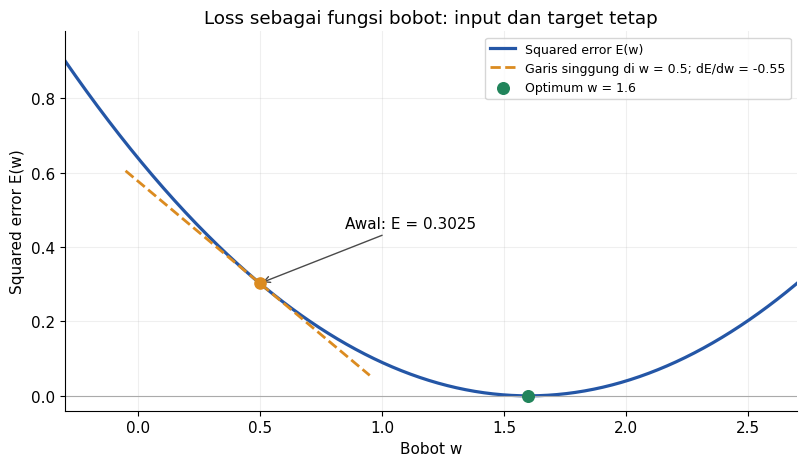

In [14]:
# Visualisasi tambahan; bukan listing Matplotlib dari buku.
x_fixed, target_fixed = 0.5, 0.8
w_start = 0.5
w_optimum = target_fixed / x_fixed
w_grid = np.linspace(-0.3, 2.7, 401)
loss_grid = (x_fixed * w_grid - target_fixed) ** 2
loss_start = (x_fixed * w_start - target_fixed) ** 2
full_slope = 2 * x_fixed * (x_fixed * w_start - target_fixed)
tangent_w = np.linspace(-0.05, 0.95, 80)
tangent_loss = loss_start + full_slope * (tangent_w - w_start)

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(w_grid, loss_grid, color='#2456a6', linewidth=2.3, label='Squared error E(w)')
ax.plot(tangent_w, tangent_loss, '--', color='#db8b20',
        linewidth=2, label='Garis singgung di w = 0.5; dE/dw = -0.55')
ax.scatter([w_start], [loss_start], s=65, color='#db8b20', zorder=4)
ax.scatter([w_optimum], [0], s=70, color='#21845b', zorder=4, label='Optimum w = 1.6')
ax.annotate('Awal: E = 0.3025', xy=(w_start, loss_start), xytext=(0.85, 0.45),
            arrowprops={'arrowstyle': '->', 'color': '#4a4a4a'})
ax.set(title='Loss sebagai fungsi bobot: input dan target tetap',
       xlabel='Bobot w', ylabel='Squared error E(w)', xlim=(-0.3, 2.7), ylim=(-0.04, 0.98))
ax.axhline(0, color='#aaaaaa', linewidth=0.8)
ax.grid(alpha=0.2)
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
plt.show()

## 17. How to use a derivative to learn — faktor 2 yang perlu diperjelas

**Pendalaman matematis tambahan:** buku menampilkan squared error $E=(xw-y)^2$, tetapi menggunakan `weight_delta = x * (pred - goal_pred)`. Kedua rumus itu perlu dibedakan secara tepat.

Aturan rantai untuk squared error penuh menghasilkan:

$$
\frac{dE}{dw}
=2(xw-y)\frac{d(xw-y)}{dw}
=2x(xw-y)
$$

Kode buku memakai:

$$
g=x(xw-y)=\frac{dJ}{dw},\qquad J=\frac12(xw-y)^2=\frac12E
$$

Jadi, `weight_delta` merupakan gradien **setengah squared error**. Mengalikan loss dengan konstanta positif tidak mengubah lokasi minimum, tetapi mengubah skala gradien. Jika gradien $E$ penuh digunakan, learning rate perlu disesuaikan agar update sama. Notebook mempertahankan rumus update buku.

Penjelasan konvensi $\tfrac12$ pada squared loss juga terdapat pada [catatan resmi Stanford CS229, bagian Linear Regression](https://cs229.stanford.edu/summer2023/cs229-notes1.pdf), hlm. 4-5. Derivasi untuk angka dan model bab ini dituliskan di atas sebagai pendalaman.

### Arah gradien dan perubahan bobot

Yang diperlukan adalah turunan **loss terhadap bobot**, $dJ/dw$, bukan turunan bobot terhadap loss. Update menuju arah berlawanan dengan gradien:

$$w_{t+1}=w_t-\alpha g_t$$

Gradien positif membuat bobot turun; gradien negatif membuat bobot naik, untuk alpha positif. Besar langkah tetap perlu dibatasi agar pendekatan lokal tidak menghasilkan overshoot berlebihan.

### Klarifikasi angka pada diagram buku

Untuk input `0.5`, bobot `0.5`, dan target `0.8`:

| Besaran | Nilai |
| --- | --- |
| Prediksi $xw$ | $0.25$ |
| Residual $xw-y$ | $-0.55$ |
| Squared error $E$ | $0.3025$ |
| Gradien kode buku $g=dJ/dw$ | $-0.275$ |
| Turunan squared error penuh $dE/dw$ | $-0.55$ |

Diagram hlm. 68 dan 70 memberi label gradien `-0.3025`. Angka tersebut tidak cocok dengan turunan kedua definisi loss di atas. Loss, residual, dan gradien adalah besaran yang berbeda; gradien tidak diperoleh dengan sekadar memberi tanda negatif pada loss.

**Rujukan:** Trask (2019), hlm. 56, 68, dan 70; Stanford CS229, hlm. 4-5 untuk konvensi half squared loss.

In [15]:
# Pemeriksaan tambahan memakai central finite difference dari loss penuh.
x_value, w_value, target = 0.5, 0.5, 0.8
epsilon_fd = 1e-6

def squared_loss_for_weight(w_value):
    return (x_value * w_value - target) ** 2

finite_difference = (
    squared_loss_for_weight(w_value + epsilon_fd)
    - squared_loss_for_weight(w_value - epsilon_fd)
) / (2 * epsilon_fd)
book_gradient = x_value * (x_value * w_value - target)
full_loss_gradient = 2 * book_gradient

print('Squared error:', squared_loss_for_weight(w_value))
print('Gradien kode buku (dJ/dw):', book_gradient)
print('Turunan analitis loss penuh (dE/dw):', full_loss_gradient)
print('Pendekatan finite difference:', finite_difference)
np.testing.assert_allclose(finite_difference, full_loss_gradient, rtol=1e-8, atol=1e-9)
print('Pemeriksaan finite difference: LULUS')

Squared error: 0.30250000000000005
Gradien kode buku (dJ/dw): -0.275
Turunan analitis loss penuh (dE/dw): -0.55
Pendekatan finite difference: -0.5500000000158156
Pemeriksaan finite difference: LULUS


## 18. Breaking gradient descent: baseline input 0,5

**Asal kode:** reproduksi listing hlm. 72 dengan variabel `delta` dan `weight_delta`. Secara matematis, loop ini sama dengan bagian 10. Pengulangan dipertahankan karena buku menggunakan baseline ini sebelum mengganti input menjadi `2`.

Tanpa alpha eksplisit, learning rate bernilai `1`. Untuk input `0.5`, error mengecil. Bagian berikut mengubah satu hal saja pada contoh buku, yaitu input, sehingga penyebab perubahan perilakunya dapat diamati.

In [16]:
# Reproduksi baseline hlm. 72.
weight = 0.5
goal_pred = 0.8
input_data = 0.5
baseline_history = []

for iteration in range(20):
    pred = input_data * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = input_data * delta
    baseline_history.append({
        'iteration': iteration, 'weight': weight,
        'prediction': pred, 'error': error,
    })
    weight = weight - weight_delta
    print('Error:' + str(error) + ' Prediction:' + str(pred))

baseline_final_weight = weight
print('Weight setelah update terakhir:', weight)

Error:0.30250000000000005 Prediction:0.25
Error:0.17015625000000004 Prediction:0.3875
Error:0.095712890625 Prediction:0.49062500000000003
Error:0.05383850097656251 Prediction:0.56796875
Error:0.03028415679931642 Prediction:0.6259765625
Error:0.0170348381996155 Prediction:0.669482421875
Error:0.00958209648728372 Prediction:0.70211181640625
Error:0.005389929274097089 Prediction:0.7265838623046875
Error:0.0030318352166796153 Prediction:0.7449378967285156
Error:0.0017054073093822882 Prediction:0.7587034225463867
Error:0.0009592916115275371 Prediction:0.76902756690979
Error:0.0005396015314842384 Prediction:0.7767706751823426
Error:0.000303525861459885 Prediction:0.7825780063867569
Error:0.00017073329707118678 Prediction:0.7869335047900676
Error:9.603747960254256e-05 Prediction:0.7902001285925507
Error:5.402108227642978e-05 Prediction:0.7926500964444131
Error:3.038685878049206e-05 Prediction:0.7944875723333098
Error:1.7092608064027242e-05 Prediction:0.7958656792499823
Error:9.614592036015323

## 19. Input 2: overcorrection dan divergence

**Asal kode:** eksperimen yang diminta buku pada hlm. 72, mengganti input `0.5` menjadi `2` pada listing sebelumnya. Bobot awal, target, jumlah iterasi, dan aturan update dipertahankan.

Tiga prediksi awal adalah `1.0`, `0.2`, dan `2.6`, dengan error `0.04`, `0.36`, dan `3.24`. Model melewati target `0.8` secara bergantian dan semakin jauh. Error bertambah sembilan kali lipat setiap langkah pada kasus ini.

Hal ini terjadi karena perubahan bobot yang sama lebih kuat memengaruhi prediksi ketika input lebih besar; selain itu, input juga memperbesar gradien. Secara gabungan, faktor yang menentukan stabilitas mengandung $x^2$. Learning rate `1` terlalu besar untuk input `2` pada model ini.

**Divergence** berarti iterasi semakin menjauh dari optimum. Kode Python dapat berjalan tanpa error sintaks atau exception sementara proses belajarnya gagal secara numerik.

**Rujukan:** Trask (2019), hlm. 72-74.

In [17]:
# Percobaan input = 2 berdasarkan hlm. 72; 20 iterasi yang sama.
weight = 0.5
goal_pred = 0.8
input_data = 2
divergence_history = []

for iteration in range(20):
    pred = input_data * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = input_data * delta
    divergence_history.append({
        'iteration': iteration, 'weight': weight, 'prediction': pred,
        'error': error, 'delta': delta, 'gradient': weight_delta,
    })
    weight = weight - weight_delta
    print('Error:' + str(error) + ' Prediction:' + str(pred))

divergence_final_weight = weight
divergence_final_error = (input_data * weight - goal_pred) ** 2
print('Weight setelah 20 update:', divergence_final_weight)
print('Error setelah 20 update:', divergence_final_error)

Error:0.03999999999999998 Prediction:1.0
Error:0.3599999999999998 Prediction:0.20000000000000018
Error:3.2399999999999984 Prediction:2.5999999999999996
Error:29.159999999999986 Prediction:-4.599999999999999
Error:262.4399999999999 Prediction:16.999999999999996
Error:2361.959999999998 Prediction:-47.79999999999998
Error:21257.639999999978 Prediction:146.59999999999994
Error:191318.75999999983 Prediction:-436.5999999999998
Error:1721868.839999999 Prediction:1312.9999999999995
Error:15496819.559999991 Prediction:-3935.799999999999
Error:139471376.03999993 Prediction:11810.599999999997
Error:1255242384.3599997 Prediction:-35428.59999999999
Error:11297181459.239996 Prediction:106288.99999999999
Error:101674633133.15994 Prediction:-318863.79999999993
Error:915071698198.4395 Prediction:956594.5999999997
Error:8235645283785.954 Prediction:-2869780.599999999
Error:74120807554073.56 Prediction:8609344.999999996
Error:667087267986662.1 Prediction:-25828031.799999986
Error:6003785411879960.0 Predi

### Visualizing overcorrections

Tabel berikut dicetak dari hasil perhitungan, bukan angka yang dimasukkan secara manual. Bobot optimum untuk input `2` dan target `0.8` adalah `0.4`. Dari bobot awal `0.5`, update pertama menuju `0.1`; update berikutnya menuju `1.3`. Jarak terhadap `0.4` bertambah, bukan menyusut.

`weight_delta` dan `delta` berganti tanda, tetapi pergantian tanda saja belum menentukan apakah pembelajaran berhasil. Bandingkan besar error antar iterasi dan besar jarak terhadap optimum.

**Rujukan:** Trask (2019), hlm. 73-74.

In [18]:
# Tabel tambahan untuk tiga iterasi pertama dari eksperimen divergence.
print('Iterasi | Weight sebelum | Prediction | Delta | Weight delta | Error')
for row in divergence_history[:3]:
    print(f"{row['iteration']:7d} | {row['weight']:14.3f} | "
          f"{row['prediction']:10.3f} | {row['delta']:5.3f} | "
          f"{row['gradient']:12.3f} | {row['error']:.6f}")

first_losses = np.array([row['error'] for row in divergence_history[:3]])
print('Rasio error langkah berikut / sebelumnya:', first_losses[1:] / first_losses[:-1])

Iterasi | Weight sebelum | Prediction | Delta | Weight delta | Error
      0 |          0.500 |      1.000 | 0.200 |        0.400 | 0.040000
      1 |          0.100 |      0.200 | -0.600 |       -1.200 | 0.360000
      2 |          1.300 |      2.600 | 1.800 |        3.600 | 3.240000
Rasio error langkah berikut / sebelumnya: [9. 9.]


## 20. Introducing alpha: mengendalikan besar update

Learning rate `alpha` mengalikan gradien sebelum update:

$$w_{t+1}=w_t-\alpha\,x(xw_t-y)$$

Dengan alpha lebih kecil, langkah bobot menjadi lebih kecil. Pada input `2`, alpha `0.1` membuat prediksi mendekati target kembali. Alpha sangat kecil dapat memperlambat kemajuan; alpha terlalu besar dapat menyebabkan osilasi atau divergence. Alpha negatif menggerakkan bobot searah gradien dan, pada contoh kuadratik ini, meningkatkan error ketika bobot belum optimal.

Alpha bukan probabilitas dan tidak mempunyai batas universal antara nol dan satu. Nilai yang stabil bergantung pada sensitivitas model serta skala input. Pada contoh buku, alpha ditentukan sebelum training dan tetap selama loop.

**Rujukan:** Trask (2019), hlm. 75-76.

## 21. Alpha in code

**Asal kode:** reproduksi hlm. 76 dengan bobot awal `0.5`, target `0.8`, input `2`, alpha `0.1`, dan 20 iterasi.

Variabel `derivative` di listing ini tetap memakai gradien dari $J=\tfrac12E$. Error yang ditampilkan adalah $E$. Setelah setiap update, jarak bobot terhadap `0.4` menjadi `0.6` kali jarak sebelumnya dan error menjadi `0.36` kali error sebelumnya.

Log terakhir dan error setelah update ke-20 ditampilkan terpisah agar urutan waktunya jelas.

In [19]:
# Reproduksi hlm. 76.
weight = 0.5
goal_pred = 0.8
input_data = 2
alpha = 0.1
alpha_history = []

for iteration in range(20):
    pred = input_data * weight
    error = (pred - goal_pred) ** 2
    derivative = input_data * (pred - goal_pred)
    alpha_history.append({
        'iteration': iteration, 'weight': weight,
        'prediction': pred, 'error': error, 'gradient': derivative,
    })
    weight = weight - (alpha * derivative)
    print('Error:' + str(error) + ' Prediction:' + str(pred))

alpha_final_weight = weight
alpha_final_pred = input_data * weight
alpha_final_error = (alpha_final_pred - goal_pred) ** 2
print()
print('Setelah update ke-20:')
print('Weight:', alpha_final_weight)
print('Prediction:', alpha_final_pred)
print('Error:', alpha_final_error)

Error:0.03999999999999998 Prediction:1.0
Error:0.0144 Prediction:0.92
Error:0.005183999999999993 Prediction:0.872
Error:0.0018662400000000014 Prediction:0.8432000000000001
Error:0.0006718464000000028 Prediction:0.8259200000000001
Error:0.00024186470400000033 Prediction:0.815552
Error:8.70712934399997e-05 Prediction:0.8093312
Error:3.134566563839939e-05 Prediction:0.80559872
Error:1.1284439629823931e-05 Prediction:0.803359232
Error:4.062398266736526e-06 Prediction:0.8020155392
Error:1.4624633760252567e-06 Prediction:0.8012093235200001
Error:5.264868153690924e-07 Prediction:0.8007255941120001
Error:1.8953525353291194e-07 Prediction:0.8004353564672001
Error:6.82326912718715e-08 Prediction:0.8002612138803201
Error:2.456376885786678e-08 Prediction:0.8001567283281921
Error:8.842956788836216e-09 Prediction:0.8000940369969153
Error:3.1834644439835434e-09 Prediction:0.8000564221981492
Error:1.1460471998340758e-09 Prediction:0.8000338533188895
Error:4.125769919393652e-10 Prediction:0.80002031199

## 22. Eksperimen alpha kecil, besar, nol, dan negatif

**Asal kode:** tambahan untuk pertanyaan pada hlm. 76. Fungsi berikut mengemas aturan update buku tanpa mengubah rumus gradien. Setiap percobaan memulai bobot dari `0.5`, input `2`, dan target `0.8`, sehingga perbedaan hasil disebabkan pilihan alpha.

Trajectory menyimpan kondisi awal sebagai langkah `0` serta kondisi setelah setiap update. Karena ada 20 update, trajectory mempunyai 21 titik. Ini berbeda dari log buku yang menyimpan 20 kondisi sebelum update.

| Alpha | Faktor jarak $1-4\alpha$ | Perilaku yang diprediksi untuk bobot awal contoh |
| --- | --- | --- |
| $0.001$ | $0.996$ | Mendekati optimum dengan lambat |
| $0.1$ | $0.6$ | Konvergen tanpa berganti sisi |
| $0.25$ | $0$ | Mencapai optimum dalam satu update |
| $0.5$ | $-1$ | Osilasi dengan besar error tetap |
| $1.0$ | $-3$ | Divergence dengan pergantian sisi |
| $0$ | $1$ | Bobot tidak berubah |
| $-0.1$ | $1.4$ | Divergence |

Prediksi perilaku berasal dari analisis model satu bobot, bukan hasil yang diasumsikan untuk semua neural network.

In [20]:
# Helper eksperimen tambahan: state 0 adalah sebelum update pertama.
def run_gradient_descent(input_data, target, initial_weight, alpha, updates):
    weight = float(initial_weight)
    history = []
    for step in range(updates + 1):
        prediction = input_data * weight
        loss = (prediction - target) ** 2
        history.append({
            'step': step, 'weight': weight, 'prediction': prediction, 'error': loss,
        })
        if step < updates:
            gradient = input_data * (prediction - target)
            weight -= alpha * gradient
    return history

alpha_choices = [0.001, 0.1, 0.25, 0.5, 1.0, 0.0, -0.1]
alpha_experiments = {
    a: run_gradient_descent(2.0, 0.8, 0.5, a, 20)
    for a in alpha_choices
}
print('Alpha | Faktor jarak | Weight setelah 20 update | Error awal | Error akhir')
for a in alpha_choices:
    trace = alpha_experiments[a]
    print(f"{a:6.3f} | {1 - a * 2 ** 2:12.3f} | "
          f"{trace[-1]['weight']:24.9f} | {trace[0]['error']:.6f} | "
          f"{trace[-1]['error']:.6e}")
print()
print('Alpha 0.25, setelah satu update:', alpha_experiments[0.25][1])

Alpha | Faktor jarak | Weight setelah 20 update | Error awal | Error akhir
 0.001 |        0.996 |              0.492296826 | 0.040000 | 3.407482e-02
 0.100 |        0.600 |              0.400003656 | 0.040000 | 5.346998e-11
 0.250 |        0.000 |              0.400000000 | 0.040000 | 0.000000e+00
 0.500 |       -1.000 |              0.500000000 | 0.040000 | 4.000000e-02
 1.000 |       -3.000 |      348678440.499999881 | 0.040000 | 4.863066e+17
 0.000 |        1.000 |              0.500000000 | 0.040000 | 4.000000e-02
-0.100 |        1.400 |             84.068255425 | 0.040000 | 2.800151e+04

Alpha 0.25, setelah satu update: {'step': 1, 'weight': 0.4, 'prediction': 0.8, 'error': 0.0}


### Grafik pengaruh learning rate

Grafik memakai **sumbu error logaritmik** agar loss yang mengecil hingga sekitar $10^{-11}$ dan loss yang membesar hingga sekitar $10^{17}$ dapat dibandingkan. Selisih vertikal menyatakan rasio, bukan selisih absolut. Garis menurun menunjukkan error berkurang; garis datar menunjukkan error tetap; garis naik menunjukkan divergence.

Kurva alpha `0.25` tidak dimasukkan karena loss menjadi nol, sedangkan nol tidak mempunyai logaritma. Hasil kasus itu tetap tersedia pada tabel keluaran sebelumnya. Alpha `0` juga tidak digambar karena errornya berimpit dengan kasus alpha `0.5` pada contoh ini, meskipun bobotnya berperilaku berbeda.

**Asal grafik:** visualisasi tambahan dari trajectory eksperimen. Penggunaan sumbu log mengikuti [dokumentasi resmi Matplotlib tentang `semilogy`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.semilogy.html).

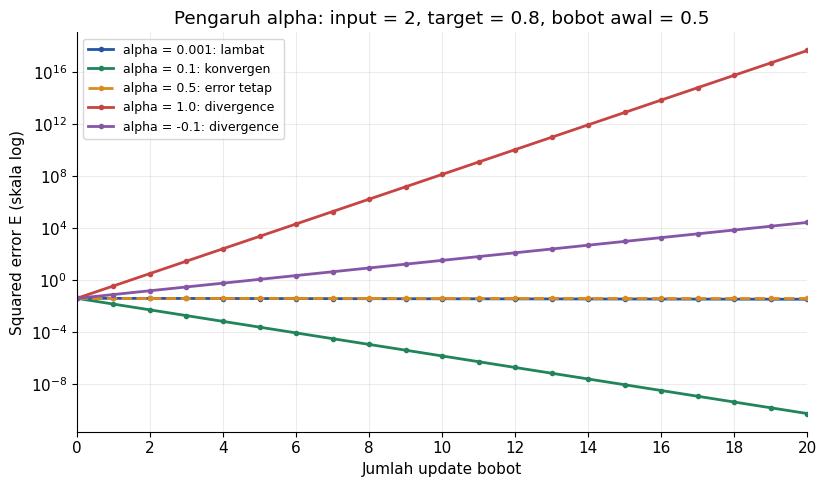

In [21]:
# Visualisasi tambahan: error sesudah 0 sampai 20 update.
plot_options = [
    (0.001, '#2456a6', 'alpha = 0.001: lambat', '-'),
    (0.1, '#21845b', 'alpha = 0.1: konvergen', '-'),
    (0.5, '#db8b20', 'alpha = 0.5: error tetap', '--'),
    (1.0, '#c74444', 'alpha = 1.0: divergence', '-'),
    (-0.1, '#8556a6', 'alpha = -0.1: divergence', '-'),
]
fig, ax = plt.subplots(figsize=(8.4, 5.0))
for a, color, label, style in plot_options:
    trace = alpha_experiments[a]
    steps = [row['step'] for row in trace]
    losses = [row['error'] for row in trace]
    ax.semilogy(steps, losses, linestyle=style, color=color,
                linewidth=2, marker='o', markersize=3, label=label)
ax.set(title='Pengaruh alpha: input = 2, target = 0.8, bobot awal = 0.5',
       xlabel='Jumlah update bobot', ylabel='Squared error E (skala log)', xlim=(0, 20))
ax.set_xticks(np.arange(0, 21, 2))
ax.grid(which='major', alpha=0.23)
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

## 23. Pendalaman teori: menurunkan syarat konvergensi

Bagian ini adalah **analisis tambahan**, bukan listing maupun hasil yang dinyatakan persis demikian dalam buku. Berlaku untuk **satu sampel, satu bobot, tanpa bias**, dengan input dan alpha tetap, serta gradien $g=x(xw-y)$ yang dipakai kode buku.

Jika $x\ne0$, bobot optimum adalah $w^*=y/x$. Definisikan selisih bobot terhadap optimum $e_t=w_t-w^*$. Karena $xw^*=y$:

$$
\begin{aligned}
w_{t+1} &= w_t-\alpha x(xw_t-y),\\
w_{t+1}-w^* &= (w_t-w^*)-\alpha x^2(w_t-w^*),\\
e_{t+1} &= (1-\alpha x^2)e_t.
\end{aligned}
$$

Dengan $r=1-\alpha x^2$, solusi setelah $t$ update adalah:

$$w_t=w^*+r^t(w_0-w^*)$$

Untuk membuat jarak dari bobot awal mana pun menyusut menuju nol, diperlukan:

$$|1-\alpha x^2|<1\quad\Longleftrightarrow\quad0<\alpha x^2<2$$

Artinya, untuk $x\ne0$, batas learning rate pada contoh ini adalah $0<\alpha<2/x^2$.

| Nilai faktor $r$ | Perilaku untuk bobot awal yang belum optimum |
| --- | --- |
| $0<r<1$ | Mendekati optimum tanpa berganti sisi |
| $r=0$ | Tepat ke optimum dalam satu update |
| $-1<r<0$ | Berganti sisi dengan jarak yang mengecil |
| $r=-1$ | Berganti sisi dengan jarak tetap |
| $r=1$ | Tidak ada kemajuan |
| $|r|>1$ | Jarak bertambah: divergence |

Karena residual $xw_t-y=xe_t$, loss juga mengikuti $E_{t+1}=r^2E_t$. Untuk input `2` dan alpha `1`, $r=-3$ sehingga error dikalikan `9`. Dengan alpha `0.1`, $r=0.6$ sehingga error dikalikan `0.36`. Untuk input `1.1` dan alpha `1`, $r=-0.21$: model melewati target, tetapi tetap konvergen.

**Batas penerapan:** rumus ini tidak menjadi aturan universal bagi jaringan nonlinear atau banyak parameter. Jika memakai turunan squared error penuh $2x(xw-y)$ tanpa penyesuaian alpha, faktor jaraknya menjadi $1-2\alpha x^2$ dan batas alphanya berubah menjadi $0<\alpha<1/x^2$. Faktor 2 pada definisi gradien harus konsisten dengan learning rate.

Jika input nol, $w^*=y/x$ tidak dapat digunakan. Semua bobot menghasilkan prediksi nol. Untuk target bukan nol, loss tidak dapat diturunkan dengan mengubah bobot; untuk target nol, semua bobot sudah memberi loss nol.

In [22]:
# Verifikasi tambahan: trajectory numerik dibandingkan solusi analitis.
analytic_cases = [
    (0.5, 1.0, 0.5),
    (1.1, 1.0, 0.0),
    (2.0, 1.0, 0.5),
    (2.0, 0.1, 0.5),
    (2.0, 0.25, 0.5),
    (2.0, 0.5, 0.5),
    (2.0, -0.1, 0.5),
]
for x_value, a, initial_weight in analytic_cases:
    target = 0.8
    trace = run_gradient_descent(x_value, target, initial_weight, a, 20)
    w_star = target / x_value
    factor = 1 - a * x_value ** 2
    actual_weights = np.array([row['weight'] for row in trace])
    expected_weights = w_star + factor ** np.arange(21) * (initial_weight - w_star)
    np.testing.assert_allclose(actual_weights, expected_weights, rtol=1e-10, atol=1e-12)
    print(f'x={x_value:.1f}, alpha={a:.2f}, faktor={factor:.3f}: LULUS')
print('Semua trajectory sesuai solusi analitis dalam toleransi floating point.')

x=0.5, alpha=1.00, faktor=0.750: LULUS
x=1.1, alpha=1.00, faktor=-0.210: LULUS
x=2.0, alpha=1.00, faktor=-3.000: LULUS
x=2.0, alpha=0.10, faktor=0.600: LULUS
x=2.0, alpha=0.25, faktor=0.000: LULUS
x=2.0, alpha=0.50, faktor=-1.000: LULUS
x=2.0, alpha=-0.10, faktor=1.400: LULUS
Semua trajectory sesuai solusi analitis dalam toleransi floating point.


## 24. Perbandingan hot and cold dengan gradient descent

| Aspek | Hot and cold pada hlm. 54 | Gradient descent pada bab ini |
| --- | --- | --- |
| Penentuan arah | Bandingkan error dua kandidat tetangga | Gunakan gradien dari residual dan input |
| Evaluasi prediksi per iterasi listing | Tiga | Satu, lalu hitung gradien secara analitis |
| Besar langkah bobot | Tetap: `step_amount` | Bergantung pada gradien dan alpha |
| Informasi arah | Diperoleh dari percobaan | Diperoleh dari tanda gradien |
| Masalah yang terlihat | Lambat, grid langkah, dapat berosilasi | Dapat lambat atau divergen jika alpha tidak sesuai |
| Syarat berhenti pada listing | Jumlah iterasi tetap | Jumlah iterasi tetap |

Kedua metode tidak otomatis berhenti hanya karena loss sudah kecil. Pada implementasi praktis, batas iterasi dapat dilengkapi toleransi loss, toleransi perubahan parameter, dan pemantauan hasil pada data validasi.

**Training loss dan generalisasi:** seluruh contoh bab ini memakai satu pasangan input-target. Bobot yang tepat untuk satu pasangan belum menunjukkan kemampuan prediksi pada pasangan baru. Keluaran linear juga tidak otomatis menjadi probabilitas, bahkan jika target ditulis sebagai angka `0` atau `1`.

**Rujukan:** Trask (2019), hlm. 54-57 dan 75-76. Penjelasan batas generalisasi serta kriteria berhenti tambahan merupakan pendalaman.

## 25. Verifikasi hasil reproduksi

Sel berikut memeriksa angka inti terhadap hasil perhitungan matematis. Pemeriksaan finite difference di bagian 17 menguji turunan secara independen, sedangkan bagian 23 membandingkan hasil iterasi dengan solusi analitis.

Pemeriksaan menggunakan toleransi karena bilangan desimal tidak selalu dapat diwakili tepat dalam floating point. Loss sangat kecil pada hot and cold bukan diperlakukan sebagai nol persis. Tidak ada output error Python yang dibiarkan tanpa penanganan dalam notebook.

In [23]:
# Pemeriksaan tambahan untuk hasil reproduksi utama.
np.testing.assert_allclose(compare_result['prediction'], 0.25)
np.testing.assert_allclose(compare_result['residual'], -0.55)
np.testing.assert_allclose(compare_result['error'], 0.3025)
np.testing.assert_allclose(hot_cold_one_step['up_error'], 0.004225)
np.testing.assert_allclose(hot_cold_one_step['down_error'], 0.055225)
np.testing.assert_allclose(hot_cold_one_step['new_weight'], 0.11)
assert len(hot_cold_history) == 1101
assert hot_cold_history[-1]['error'] < 1e-20
np.testing.assert_allclose(hot_cold_final_weight, 1.601, atol=1e-12)
np.testing.assert_allclose(hot_cold_final_error, 2.5e-7, rtol=1e-8, atol=1e-15)

np.testing.assert_allclose(one_gradient_step['weight_delta'], -1.275)
np.testing.assert_allclose(one_gradient_step['new_weight'], 0.11275)
np.testing.assert_allclose(one_gradient_step['new_prediction'], 0.958375)
np.testing.assert_allclose(one_gradient_step['new_error'], 0.001732640625)

np.testing.assert_allclose(
    [row['prediction'] for row in four_half_history], [0, 0.2, 0.35, 0.4625])
np.testing.assert_allclose(four_half_final_weight, 1.09375)
np.testing.assert_allclose(
    [row['prediction'] for row in four_large_history], [0, 0.968, 0.76472, 0.8074088])
np.testing.assert_allclose(four_large_final_weight, 0.72585832)
np.testing.assert_allclose(
    [row['error'] for row in divergence_history[:3]], [0.04, 0.36, 3.24])
np.testing.assert_allclose(
    [row['error'] for row in alpha_history[:3]], [0.04, 0.0144, 0.005184])
np.testing.assert_allclose(baseline_final_weight, direction_final_weight)
np.testing.assert_allclose(alpha_final_weight, alpha_experiments[0.1][-1]['weight'])

assert alpha_final_error < 1e-10
assert direction_final_error < direction_history[0]['error']
assert divergence_final_error > divergence_history[0]['error']
assert alpha_experiments[0.25][1]['error'] == 0.0
np.testing.assert_allclose(
    [row['error'] for row in alpha_experiments[0.5]], 0.04, atol=1e-14)
print('Verifikasi nilai prediksi, error, bobot, dan perilaku pembelajaran: LULUS.')

Verifikasi nilai prediksi, error, bobot, dan perilaku pembelajaran: LULUS.
